In [1]:
!pip install scikit-learn-extra

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 12.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp313-cp313-linux_x86_64.whl size=2114456 sha256=77f194c5ef141fae307b02d4af50ea223bec4600797360eff1cf4b28e25b37a3
  Stored in directory: /root/.cache/pip/wheels/17/4b/b8/6b6711681d0981b110c9cc91ad6d1ebd88adf1547e1da301fc
Successfully built scikit-learn-extra


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn_extra.cluster import KMedoids

In [3]:
data=pd.read_csv("rainfall.csv")
data

,date,rainfall,temperature,humidity,wind_speed,weather_condition
0,2022-01-01,12.5,15.2,78.0,8.5,Rainy
1,2022-01-02,8.2,17.8,65.0,5.2,Rainy
2,2022-01-03,0.0,20.1,52.0,3.1,Sunny
3,2022-01-04,3.7,18.6,71.0,6.7,Rainy
4,2022-01-05,21.1,14.8,82.0,9.3,Rainy
5,2022-01-06,15.3,16.5,75.0,7.8,Rainy
6,2022-01-07,6.8,19.2,61.0,4.5,Rainy
7,2022-01-08,0.0,21.7,48.0,2.9,Sunny
8,2022-01-09,11.2,17.3,73.0,6.1,Rainy
9,2022-01-10,18.6,15.8,79.0,8.9,Rainy


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               54 non-null     object 
 1   rainfall           53 non-null     float64
 2   temperature        53 non-null     float64
 3   humidity           53 non-null     float64
 4   wind_speed         53 non-null     float64
 5   weather_condition  53 non-null     object 
dtypes: float64(4), object(2)
memory usage: 2.7+ KB


In [5]:
data.describe()

,rainfall,temperature,humidity,wind_speed
count,53.000000,53.000000,53.000000,53.000000
mean,9.049057,17.950943,69.245283,6.403774
std,6.712521,2.500663,11.969361,2.209069
min,0.000000,13.900000,44.000000,2.100000
25%,3.900000,16.100000,62.000000,4.700000
50%,8.300000,17.800000,72.000000,6.700000
75%,14.800000,19.400000,78.000000,8.300000
max,21.800000,23.400000,89.000000,10.500000


In [6]:
data.columns

Index(['date', 'rainfall', 'temperature', 'humidity', 'wind_speed',
       'weather_condition'],
      dtype='object')

In [7]:
data.isnull().sum()

,0
date,0
rainfall,1
temperature,1
humidity,1
wind_speed,1
weather_condition,1


In [8]:
data=data.drop(index=53)
data

,date,rainfall,temperature,humidity,wind_speed,weather_condition
0,2022-01-01,12.5,15.2,78.0,8.5,Rainy
1,2022-01-02,8.2,17.8,65.0,5.2,Rainy
2,2022-01-03,0.0,20.1,52.0,3.1,Sunny
3,2022-01-04,3.7,18.6,71.0,6.7,Rainy
4,2022-01-05,21.1,14.8,82.0,9.3,Rainy
5,2022-01-06,15.3,16.5,75.0,7.8,Rainy
6,2022-01-07,6.8,19.2,61.0,4.5,Rainy
7,2022-01-08,0.0,21.7,48.0,2.9,Sunny
8,2022-01-09,11.2,17.3,73.0,6.1,Rainy
9,2022-01-10,18.6,15.8,79.0,8.9,Rainy


In [9]:
data.isnull().sum()

,0
date,0
rainfall,0
temperature,0
humidity,0
wind_speed,0
weather_condition,0


In [10]:
data.head()

,date,rainfall,temperature,humidity,wind_speed,weather_condition
0,2022-01-01,12.5,15.2,78.0,8.5,Rainy
1,2022-01-02,8.2,17.8,65.0,5.2,Rainy
2,2022-01-03,0.0,20.1,52.0,3.1,Sunny
3,2022-01-04,3.7,18.6,71.0,6.7,Rainy
4,2022-01-05,21.1,14.8,82.0,9.3,Rainy


In [11]:
data.tail()

,date,rainfall,temperature,humidity,wind_speed,weather_condition
48,2022-02-18,11.9,14.1,89.0,10.5,Rainy
49,2022-02-19,17.3,15.9,83.0,8.6,Rainy
50,2022-02-20,9.6,18.6,71.0,6.7,Rainy
51,2022-02-21,0.0,21.3,55.0,5.1,Sunny
52,2022-02-22,7.4,16.8,77.0,8.9,Rainy


In [12]:
data.dropna()

,date,rainfall,temperature,humidity,wind_speed,weather_condition
0,2022-01-01,12.5,15.2,78.0,8.5,Rainy
1,2022-01-02,8.2,17.8,65.0,5.2,Rainy
2,2022-01-03,0.0,20.1,52.0,3.1,Sunny
3,2022-01-04,3.7,18.6,71.0,6.7,Rainy
4,2022-01-05,21.1,14.8,82.0,9.3,Rainy
5,2022-01-06,15.3,16.5,75.0,7.8,Rainy
6,2022-01-07,6.8,19.2,61.0,4.5,Rainy
7,2022-01-08,0.0,21.7,48.0,2.9,Sunny
8,2022-01-09,11.2,17.3,73.0,6.1,Rainy
9,2022-01-10,18.6,15.8,79.0,8.9,Rainy


In [13]:
data.drop_duplicates()

,date,rainfall,temperature,humidity,wind_speed,weather_condition
0,2022-01-01,12.5,15.2,78.0,8.5,Rainy
1,2022-01-02,8.2,17.8,65.0,5.2,Rainy
2,2022-01-03,0.0,20.1,52.0,3.1,Sunny
3,2022-01-04,3.7,18.6,71.0,6.7,Rainy
4,2022-01-05,21.1,14.8,82.0,9.3,Rainy
5,2022-01-06,15.3,16.5,75.0,7.8,Rainy
6,2022-01-07,6.8,19.2,61.0,4.5,Rainy
7,2022-01-08,0.0,21.7,48.0,2.9,Sunny
8,2022-01-09,11.2,17.3,73.0,6.1,Rainy
9,2022-01-10,18.6,15.8,79.0,8.9,Rainy


In [14]:
x=data[['rainfall','temperature']]
x

,rainfall,temperature
0,12.5,15.2
1,8.2,17.8
2,0.0,20.1
3,3.7,18.6
4,21.1,14.8
5,15.3,16.5
6,6.8,19.2
7,0.0,21.7
8,11.2,17.3
9,18.6,15.8


In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
scalar=StandardScaler()
y=scalar.fit_transform(x)
y

array([[ 0.51902523, -1.11061291],
       [-0.12769894, -0.06093898],
       [-1.36098689,  0.86761872],
       [-0.8045033 ,  0.26203761],
       [ 1.81247357, -1.2721012 ],
       [ 0.94014795, -0.58577594],
       [-0.33826029,  0.50427006],
       [-1.36098689,  1.51357191],
       [ 0.32350397, -0.26279935],
       [ 1.43647115, -0.86838046],
       [ 0.06782232, -0.70689216],
       [-1.04514485,  0.7465025 ],
       [-1.36098689,  1.79617643],
       [-0.24801971, -0.02056691],
       [ 0.87998756, -1.15098498],
       [ 1.52671173, -0.46465972],
       [-0.51874146,  0.22166554],
       [-1.36098689,  1.31171154],
       [ 0.26334358, -0.14168313],
       [ 1.09054892, -1.39321742],
       [-0.77442311, -0.74726424],
       [-1.36098689,  0.58501421],
       [-0.29314   ,  0.10054932],
       [ 0.54910543, -0.90875254],
       [ 1.40639095, -0.3435435 ],
       [ 0.11294261,  0.70613043],
       [-1.36098689,  1.9980368 ],
       [-0.42850088,  0.22166554],
       [ 0.97022814,

In [17]:
kmedoids=KMedoids(n_clusters=2,random_state=42)
kmedoids.fit(x)

KMedoids(n_clusters=2, random_state=42)

In [18]:
data["clusters"]=kmedoids.labels_

In [19]:
data

,date,rainfall,temperature,humidity,wind_speed,weather_condition,clusters
0,2022-01-01,12.5,15.2,78.0,8.5,Rainy,0
1,2022-01-02,8.2,17.8,65.0,5.2,Rainy,1
2,2022-01-03,0.0,20.1,52.0,3.1,Sunny,1
3,2022-01-04,3.7,18.6,71.0,6.7,Rainy,1
4,2022-01-05,21.1,14.8,82.0,9.3,Rainy,0
5,2022-01-06,15.3,16.5,75.0,7.8,Rainy,0
6,2022-01-07,6.8,19.2,61.0,4.5,Rainy,1
7,2022-01-08,0.0,21.7,48.0,2.9,Sunny,1
8,2022-01-09,11.2,17.3,73.0,6.1,Rainy,1
9,2022-01-10,18.6,15.8,79.0,8.9,Rainy,0


/tmp/ipykernel_1429/3215529212.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


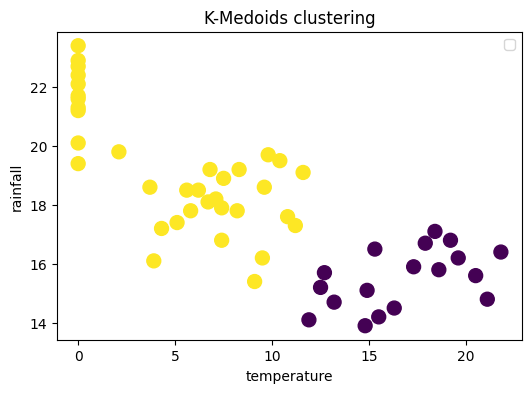

In [20]:
plt.figure(figsize=(6,4))
plt.scatter(data['rainfall'],data['temperature'],
            c=data['clusters'],
            cmap='viridis',
            s=100)
plt.xlabel("temperature")
plt.ylabel("rainfall")
plt.title("K-Medoids clustering")
plt.legend()
plt.show()